In [1]:
# Load in packages
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)
from scipy.stats import pearsonr, spearmanr
import seaborn as sns

## K562 all binding patterns scatterplots

In [21]:
k562_path = "/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/K562_all-data.feather"

k562 = pl.read_ipc(k562_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [22]:
# Clean the PPI dataframe to get rid of duplicated PPIs

ppi_k562 = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/PPI_table_k562.csv')

ppi_k562["pair"] = ppi_k562.apply(
    lambda row: tuple(sorted([row["Prey"], row["Bait"]])),
    axis=1
)

# Drop duplicates
ppi_k562_unique = ppi_k562.drop_duplicates("pair")

In [ ]:
# plot for all binding patters
positions = {1, 2, 3, 4, 5, 6}

for protein1, protein2 in ppi_k562_unique["pair"]:
    
    for pos in positions:
        
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"


        # filter valid rows
        subset = k562.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))

        if subset.height in [0, 1]:
            print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)

        print(f"{protein1}-{protein2}: Pearson r={pearson_corr:.3f} (p={pearson_pval:.3e}), "
              f"Spearman ρ={spearman_corr:.3f} (p={spearman_pval:.3e})")


        # make scatter plot
        plt.figure(figsize=(5, 5))
        plt.scatter(x, y, alpha=0.7)
        plt.xlabel(f"{protein1} SHAP")
        plt.ylabel(f"{protein2} SHAP")
        plt.title(f"K562: {protein1} vs {protein2} at Position {pos}\n" + r"$\phi_{i,j}$" + f" Correlation\n"
                  f"Pearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}, n={n_points}")
        plt.grid(False)
        #plt.show()



## K562 unique binding patterns scatterplots

In [23]:
# get the binding columns
subset_cols = k562.columns[1:835]

# unique based on them
k562_unique = k562.unique(subset=subset_cols, keep="first")

In [ ]:
# Get unique patterns

# plots for unique patterns
positions = {1, 2, 3, 4, 5, 6}

for protein1, protein2 in ppi_k562_unique["pair"]:
    
    for pos in positions:
        
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"

        # filter valid rows
        subset = k562_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))
        
        if subset.height in [0, 1]:
            print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)

        print(f"{protein1}-{protein2}: Pearson r={pearson_corr:.3f} (p={pearson_pval:.3e}), "
              f"Spearman ρ={spearman_corr:.3f} (p={spearman_pval:.3e})")


        # make scatter plot
        plt.figure(figsize=(5, 5))
        plt.scatter(x, y, alpha=0.7)
        plt.xlabel(f"{protein1} SHAP")
        plt.ylabel(f"{protein2} SHAP")
        plt.title(f"K562: {protein1} vs {protein2} at Position {pos}\n" + r"$\phi_{i,j}$" + f" Correlation\n"
                  f"Pearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}, n={n_points}")
        plt.grid(False)
        #plt.xlim(-0.02, 0.05)
        #plt.ylim(-0.02, 0.05)
        plt.show()



## HepG2 all binding patterns scatterplots

In [3]:
# Read in the HepG2 metadata

hepg2_path = "/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/HepG2_all-data.feather"

hepg2 = pl.read_ipc(hepg2_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [25]:
# Clean the PPI dataframe to get rid of duplicated PPIs

ppi_hepg2 = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/PPI_table_hepg2.csv')

ppi_hepg2["pair"] = ppi_hepg2.apply(
    lambda row: tuple(sorted([row["Prey"], row["Bait"]])),
    axis=1
)

# Drop duplicates
ppi_hepg2_unique = ppi_hepg2.drop_duplicates("pair")

In [ ]:
# Plot for all binding patterns

positions = {1, 2, 3, 4, 5, 6}

for protein1, protein2 in ppi_hepg2_unique["pair"]:
    
    for pos in positions:
        
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"

        # filter valid rows
        subset = hepg2.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))

        if subset.height in [0, 1]:
            print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)

        print(f"{protein1}-{protein2}: Pearson r={pearson_corr:.3f} (p={pearson_pval:.3e}), "
              f"Spearman ρ={spearman_corr:.3f} (p={spearman_pval:.3e})")


        # make scatter plot
        plt.figure(figsize=(5, 5))
        plt.scatter(x, y, alpha=0.7)
        plt.xlabel(f"{protein1} SHAP")
        plt.ylabel(f"{protein2} SHAP")
        plt.title(f"HepG2: {protein1} vs {protein2} at Position {pos}\n" + r"$\phi_{i,j}$" + f" Correlation\n"
                  f"Pearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}, n={n_points}")
        plt.grid(False)
        #plt.xlim(-0.1, 0.1)
        #plt.ylim(-0.1, 0.1)
        plt.show()

## HepG2 unique binding patterns scatterplots

In [26]:
# get the binding columns
subset_cols = hepg2.columns[1:631]

# unique based on them
hepg2_unique = hepg2.unique(subset=subset_cols, keep="first")

# plot for unique binding patterns

positions = {1, 2, 3, 4, 5, 6}

for protein1, protein2 in ppi_hepg2_unique["pair"]:
    
    for pos in positions:
        
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"


        # filter valid rows
        subset = hepg2_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))

        if subset.height in [0, 1]:
            print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)

        print(f"{protein1}-{protein2}: Pearson r={pearson_corr:.3f} (p={pearson_pval:.3e}), "
              f"Spearman ρ={spearman_corr:.3f} (p={spearman_pval:.3e})")


        # make scatter plot
        plt.figure(figsize=(5, 5))
        plt.scatter(x, y, alpha=0.7)
        plt.xlabel(f"{protein1} SHAP")
        plt.ylabel(f"{protein2} SHAP")
        plt.title(f"HepG2: {protein1} vs {protein2} at Position {pos}\n" + r"$\phi_{i,j}$" + f" Correlation\n"
                  f"Pearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}, n={n_points}")
        plt.grid(False)
        #plt.xlim(-0.02, 0.05)
        #plt.ylim(-0.02, 0.05)
        plt.show()

## Dataframe of Correlations

In [24]:
# K562 Unique Binding Sites Correlations Dataframe


positions = {1, 2, 3, 4, 5, 6}

# create empty results dataframe with explicit types
results_k562 = pl.DataFrame(
    {
        "Protein1": pl.Series(dtype=pl.Utf8),
        "Protein2": pl.Series(dtype=pl.Utf8),
        "Position": pl.Series(dtype=pl.Int64),
        "Pearson_Corr": pl.Series(dtype=pl.Float64),
        "Pearson_P": pl.Series(dtype=pl.Float64),
        "Spearman_Corr": pl.Series(dtype=pl.Float64),
        "Spearman_P": pl.Series(dtype=pl.Float64),
        "n": pl.Series(dtype=pl.Int64),
    }
)

for protein1, protein2 in ppi_k562_unique["pair"]:
    for pos in positions:
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"

        # filter valid rows
        subset = k562_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))
        
        if subset.height in [0, 1]:
            # print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)
    
        # append results
        results_k562 = results_k562.vstack(
            pl.DataFrame(
                {
                    "Protein1": [protein1],
                    "Protein2": [protein2],
                    "Position": [pos],
                    "Pearson_Corr": [pearson_corr],
                    "Pearson_P": [pearson_pval],
                    "Spearman_Corr": [spearman_corr],
                    "Spearman_P": [spearman_pval],
                    "n": [n_points],
                }
            )
        )
        
results_k562

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Protein1,Protein2,Position,Pearson_Corr,Pearson_P,Spearman_Corr,Spearman_P,n
str,str,i64,f64,f64,f64,f64,i64
"""BUD13""","""EFTUD2""",1,0.362251,5.9132e-35,0.386044,7.5769e-40,1084
"""BUD13""","""EFTUD2""",2,0.40055,1.0149e-121,0.487395,1.1532e-187,3150
"""BUD13""","""EFTUD2""",3,0.030079,0.248307,0.178455,5.0789e-12,1475
"""BUD13""","""EFTUD2""",4,0.74365,0.0,0.669108,2.9434e-272,2096
"""BUD13""","""EFTUD2""",5,-0.338035,1.3439e-37,-0.500678,6.1090e-87,1356
"""BUD13""","""EFTUD2""",6,0.373926,6.7755e-50,0.011211,0.667889,1467
"""BUD13""","""FMR1""",1,0.830851,1.7903e-72,0.669665,1.1531e-37,279
"""BUD13""","""FMR1""",2,0.091561,0.165451,0.241998,0.000204,231
"""BUD13""","""FMR1""",3,0.700241,2.1111e-56,0.690572,2.7183e-54,374


In [27]:
# hepg2 Unique Binding Sites Correlations Dataframe


positions = {1, 2, 3, 4, 5, 6}

# create empty results dataframe with explicit types
results_hepg2 = pl.DataFrame(
    {
        "Protein1": pl.Series(dtype=pl.Utf8),
        "Protein2": pl.Series(dtype=pl.Utf8),
        "Position": pl.Series(dtype=pl.Int64),
        "Pearson_Corr": pl.Series(dtype=pl.Float64),
        "Pearson_P": pl.Series(dtype=pl.Float64),
        "Spearman_Corr": pl.Series(dtype=pl.Float64),
        "Spearman_P": pl.Series(dtype=pl.Float64),
        "n": pl.Series(dtype=pl.Int64),
    }
)

for protein1, protein2 in ppi_hepg2_unique["pair"]:
    for pos in positions:
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"

        # filter valid rows
        subset = hepg2_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))
        
        if subset.height in [0, 1]:
            # print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)
    
        # append results
        results_hepg2 = results_hepg2.vstack(
            pl.DataFrame(
                {
                    "Protein1": [protein1],
                    "Protein2": [protein2],
                    "Position": [pos],
                    "Pearson_Corr": [pearson_corr],
                    "Pearson_P": [pearson_pval],
                    "Spearman_Corr": [spearman_corr],
                    "Spearman_P": [spearman_pval],
                    "n": [n_points],
                }
            )
        )
        
results_hepg2

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Protein1,Protein2,Position,Pearson_Corr,Pearson_P,Spearman_Corr,Spearman_P,n
str,str,i64,f64,f64,f64,f64,i64
"""BCLAF1""","""BUD13""",1,0.438592,6.7021e-41,0.409862,1.9016e-35,842
"""BCLAF1""","""BUD13""",2,0.124273,0.000753,0.4301,2.5660e-34,732
"""BCLAF1""","""BUD13""",3,0.676172,1.8399e-105,0.623414,2.6398e-85,781
"""BCLAF1""","""BUD13""",4,0.554661,6.5754e-53,0.470445,1.4735e-36,640
"""BCLAF1""","""BUD13""",5,0.728274,1.7215e-177,0.683981,1.8310e-148,1070
"""BCLAF1""","""BUD13""",6,0.650506,1.0888e-105,0.593081,1.1237e-83,869
"""BUD13""","""CDC40""",1,-0.720652,0.000002,-0.815534,7.4333e-9,33
"""BUD13""","""CDC40""",2,NaN,NaN,NaN,NaN,306
"""BUD13""","""CDC40""",3,-0.902151,1.5874e-26,-0.807647,2.9842e-17,70


## Final Heatmap

In [2]:
# Heatmap of PPI pairs and their shap correlations

k562_final = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/k562_ubp_ppi_shap_correlations.csv')

k562_final

,Protein1,Protein2,Position,Pearson_Corr,Pearson_P,Spearman_Corr,Spearman_P,n
0,BUD13,EFTUD2,1,0.362251,5.913224e-35,0.386044,7.576907e-40,1084
1,BUD13,EFTUD2,2,0.400550,1.014853e-121,0.487395,1.153180e-187,3150
2,BUD13,EFTUD2,3,0.030079,2.483068e-01,0.178455,5.078856e-12,1475
3,BUD13,EFTUD2,4,0.743650,0.000000e+00,0.669108,2.943391e-272,2096
4,BUD13,EFTUD2,5,-0.338035,1.343909e-37,-0.500678,6.109017e-87,1356
...,...,...,...,...,...,...,...,...
905,AQR,U2AF2,2,0.402112,1.500652e-16,0.678825,7.374317e-54,389
906,AQR,U2AF2,3,0.494097,1.221480e-48,0.584551,9.249757e-72,770
907,AQR,U2AF2,4,0.288197,1.302986e-09,0.255899,8.233927e-08,427
908,AQR,U2AF2,5,0.251454,5.869975e-16,-0.102029,1.199857e-03,1005


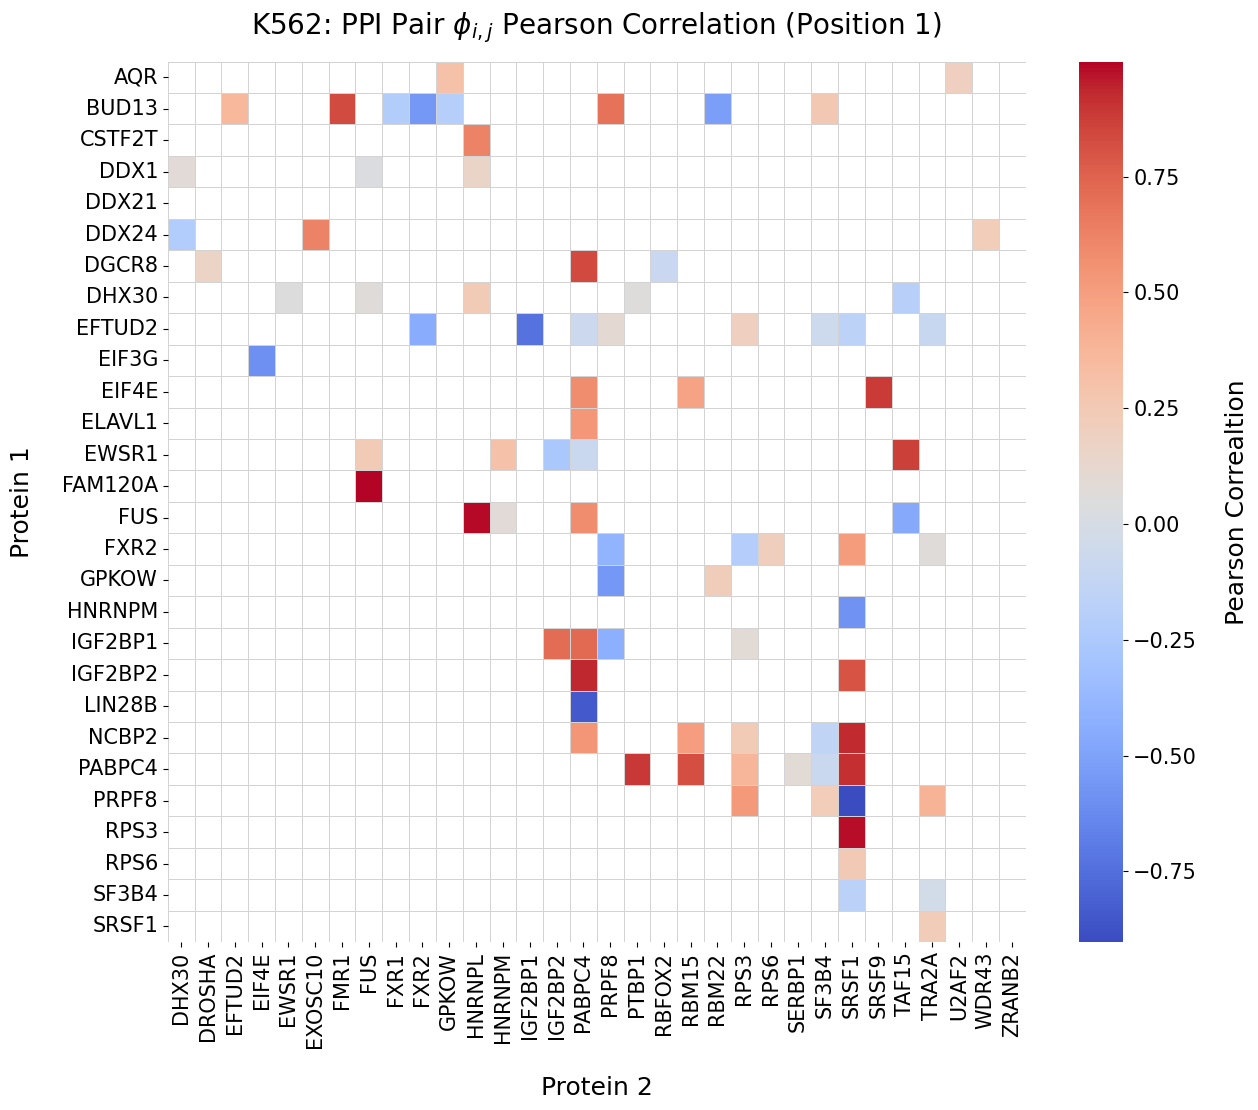

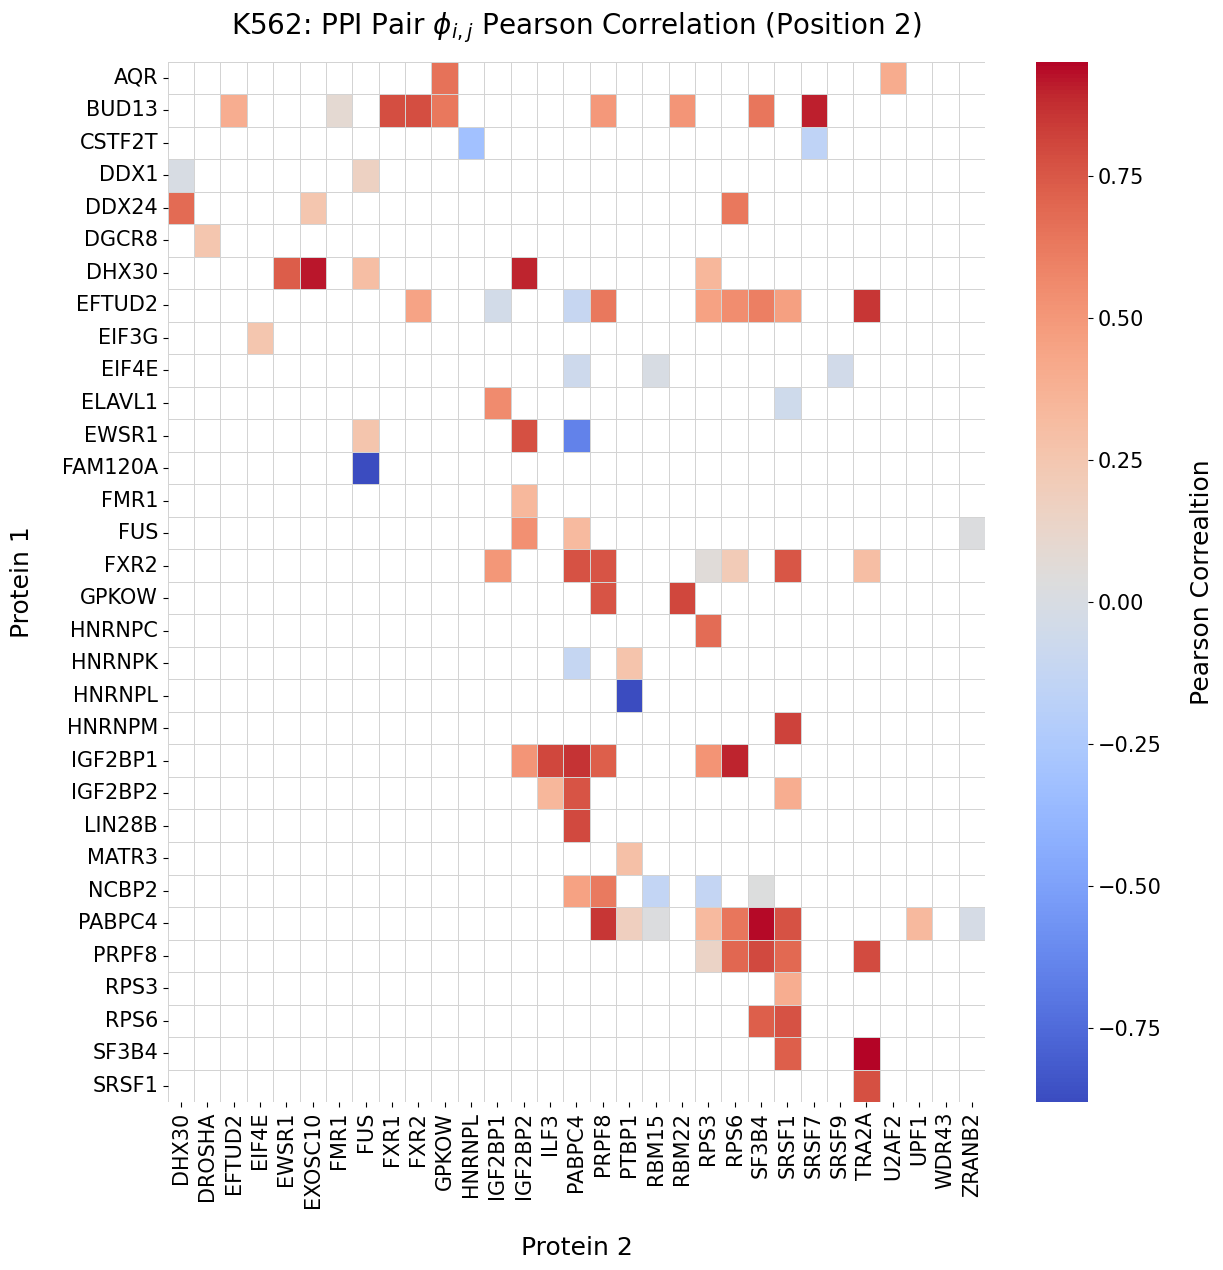

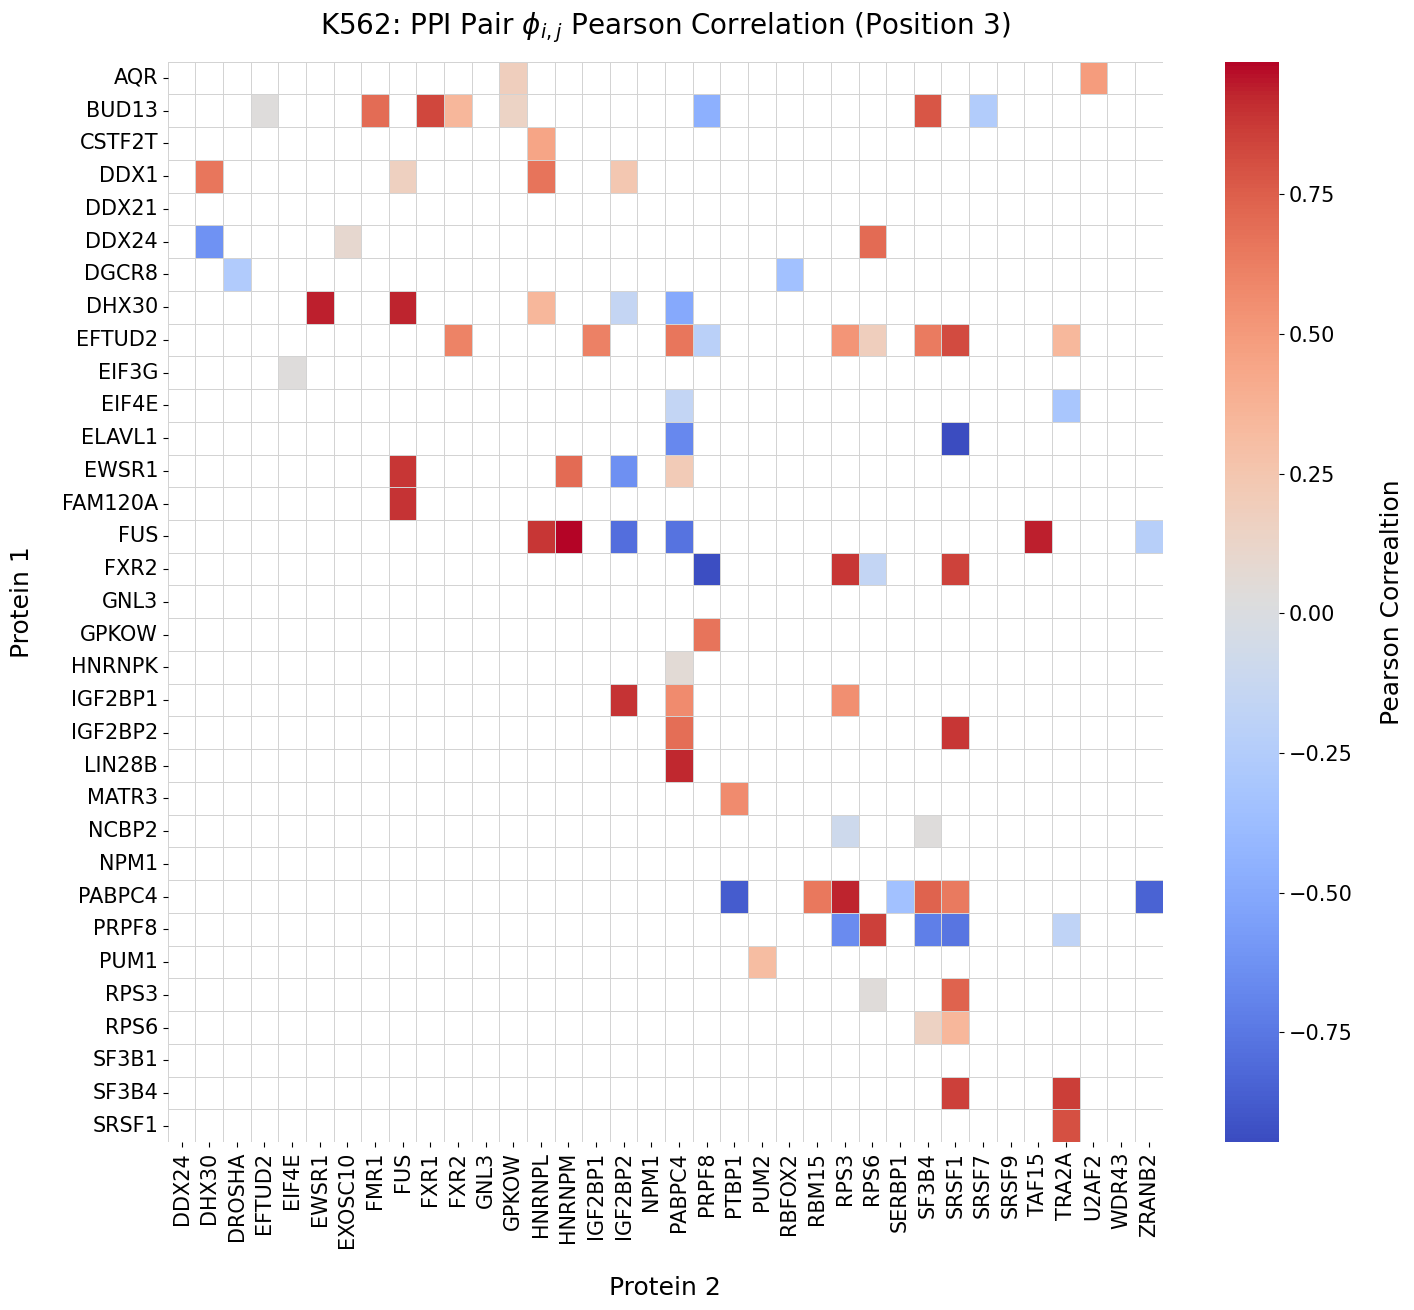

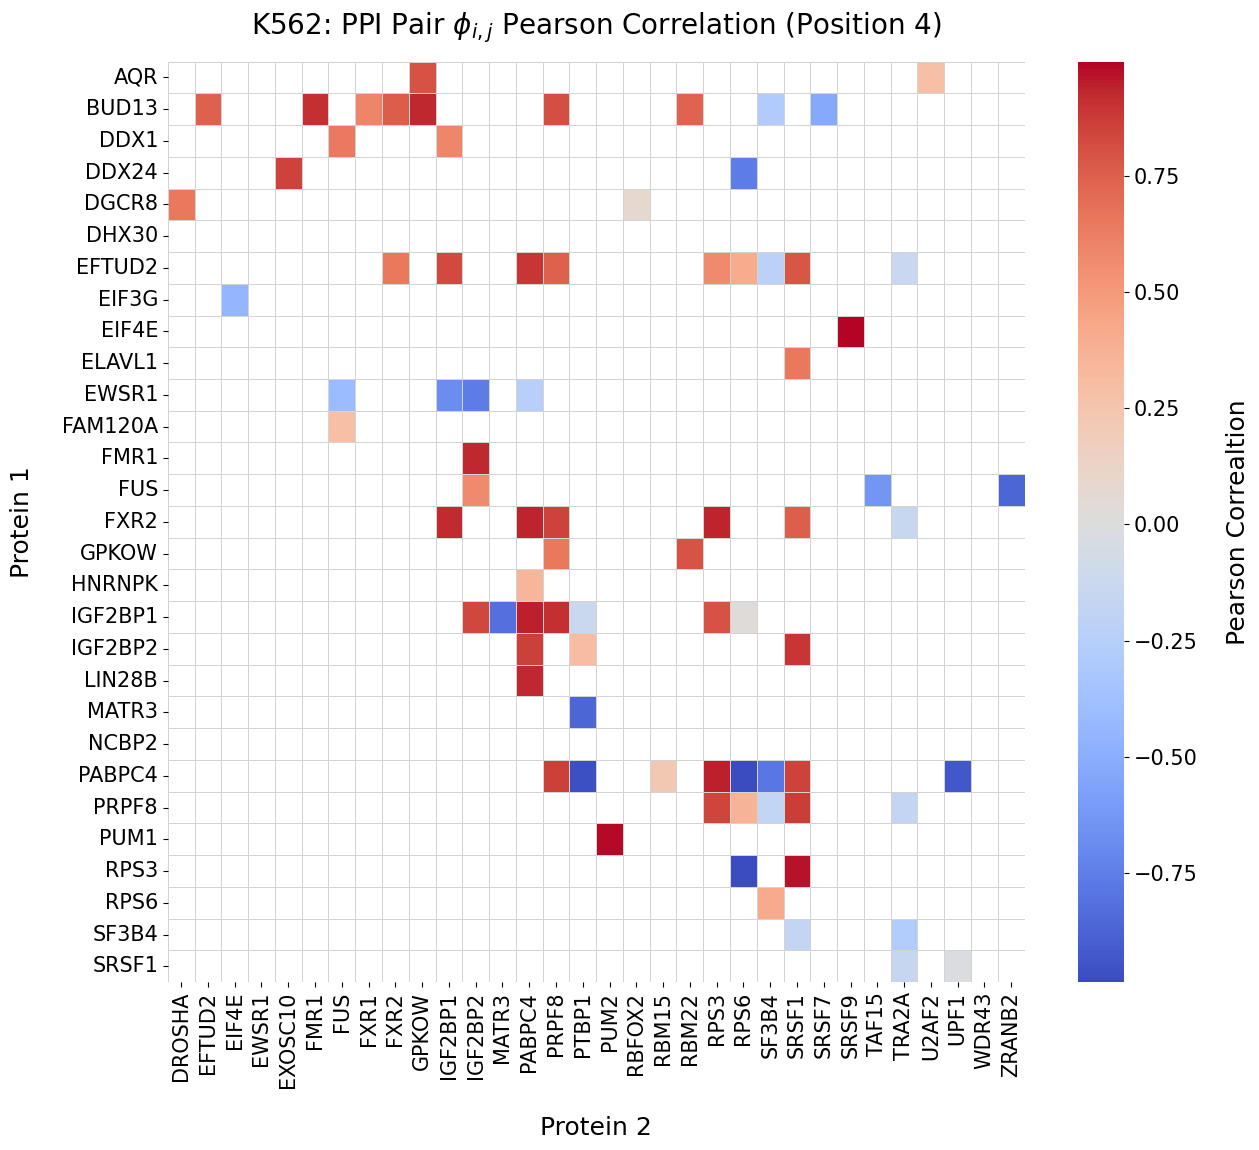

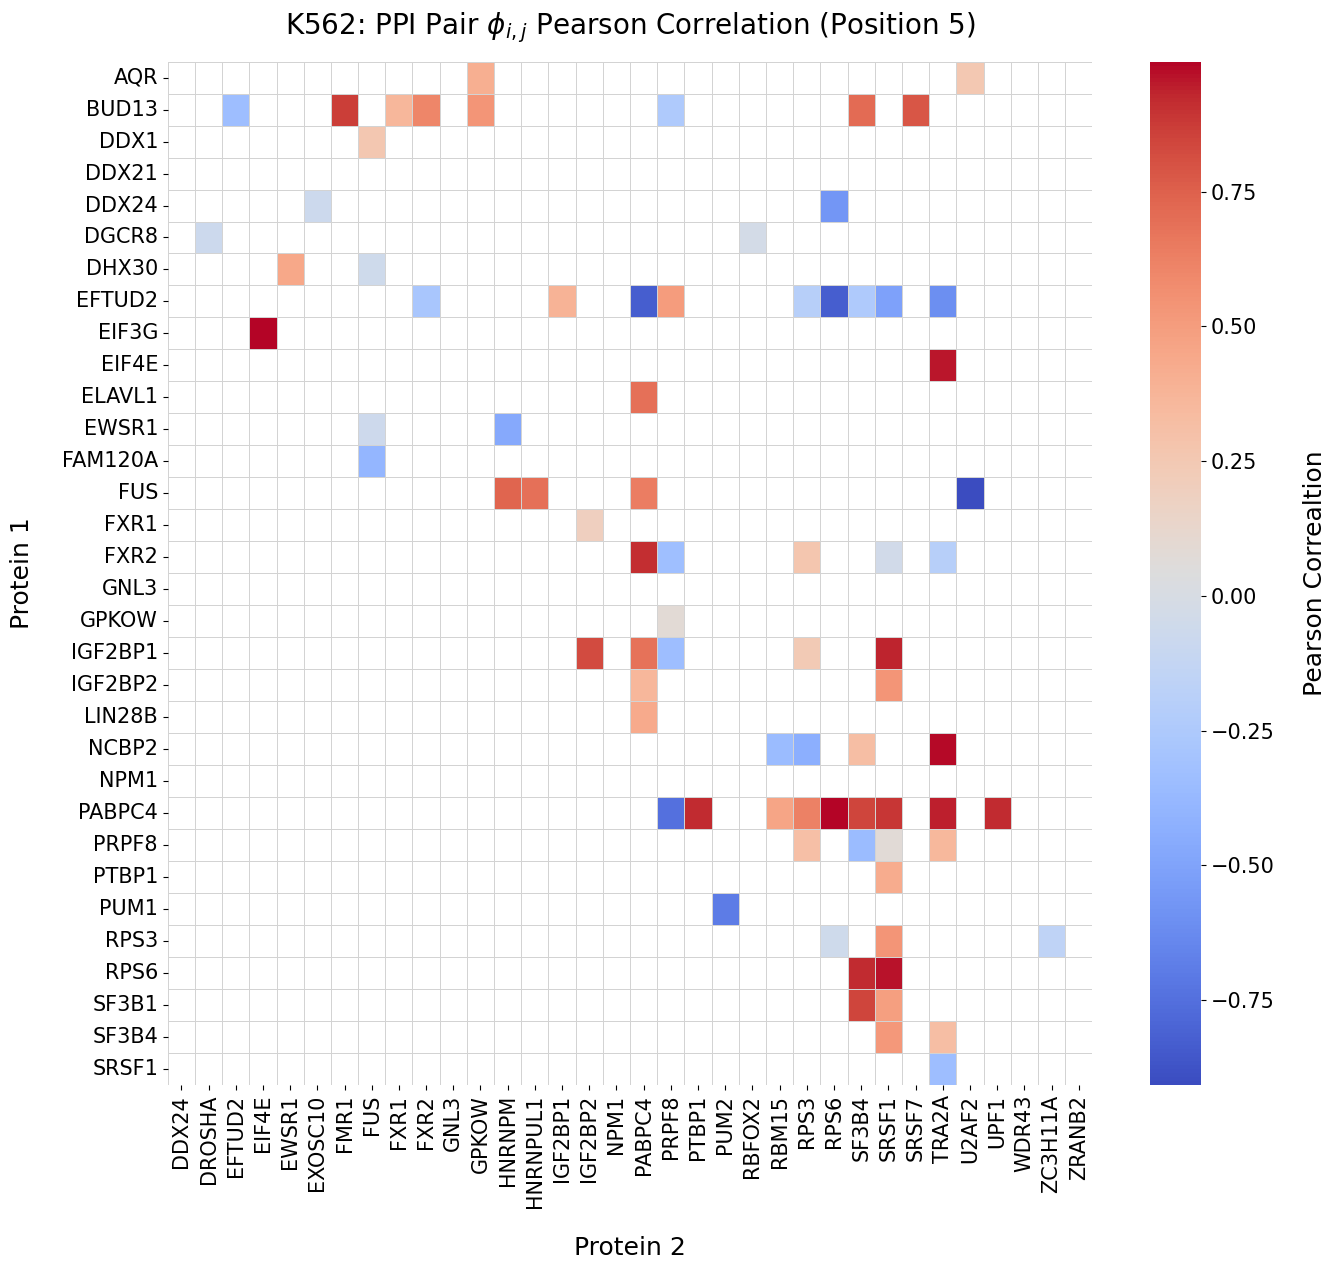

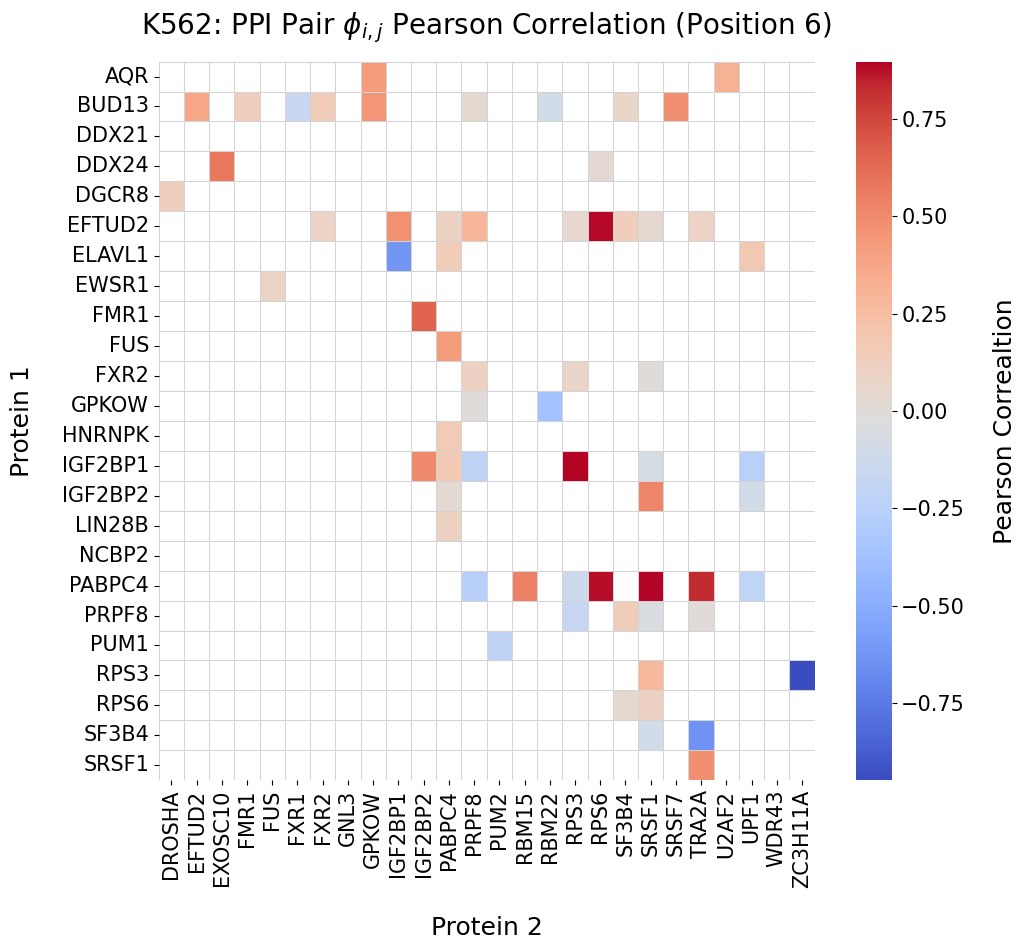

In [6]:
# Pearson Plot

# Get the unique positions
positions = k562_final["Position"].unique()

# Loop through each position
for pos in positions:
    subset = k562_final[(k562_final["Position"] == pos) & (k562_final["n"] > 30)]

    # Pivot to heatmap format
    heatmap_data = subset.pivot(
        index="Protein1",
        columns="Protein2",
        values="Pearson_Corr"
    )


    # Make figure scale with matrix size
    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, len(heatmap_data.index) * 0.4))

    ax = sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        cbar_kws={"label": "Pearson Correlation"},
        linewidths=0.5,
        linecolor="lightgray",
        square=False,
        mask=heatmap_data.isna()  # keep NaN cells white
    )

    # Get colorbar and format its label/ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)          # tick labels
    cbar.ax.set_ylabel("Pearson Correaltion", fontsize=18, labelpad=20)  # label

    # Axis labels with font size and labelpad
    plt.xlabel("Protein 2", fontsize=18, labelpad=20)
    plt.ylabel("Protein 1", fontsize=18, labelpad=20)

    # Tick labels
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(rotation=0, fontsize=15)

    # Title
    plt.title(f"K562: PPI Pair " + r"$\phi_{i,j}$" + f" Pearson Correlation (Position {pos})", fontsize=20, pad=20)

    plt.tight_layout()
    plt.show()


In [ ]:
# Spearman Plot

# Get the unique positions
positions = k562_final["Position"].unique()

# Loop through each position
for pos in positions:
    subset = k562_final[(k562_final["Position"] == pos) & (k562_final["n"] > 30)]

    # Pivot to heatmap format
    heatmap_data = subset.pivot(
        index="Protein1",
        columns="Protein2",
        values="Spearman_Corr"
    )


    # Make figure scale with matrix size
    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, len(heatmap_data.index) * 0.4))

    ax = sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        cbar_kws={"label": "Spearman Correlation"},
        linewidths=0.5,
        linecolor="lightgray",
        square=False,
        mask=heatmap_data.isna()  # keep NaN cells white
    )

    # Get colorbar and format its label/ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)          # tick labels
    cbar.ax.set_ylabel("Spearman Correaltion", fontsize=18, labelpad=20)  # label

    # Axis labels with font size and labelpad
    plt.xlabel("Protein 2", fontsize=18, labelpad=20)
    plt.ylabel("Protein 1", fontsize=18, labelpad=20)

    # Tick labels
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(rotation=0, fontsize=15)

    # Title
    plt.title(f"K562: PPI Pair " + r"$\phi_{i,j}$" + f" Spearman Correlation (Position {pos})", fontsize=20, pad=20)

    plt.tight_layout()
    plt.show()


## Distribution Plots

91


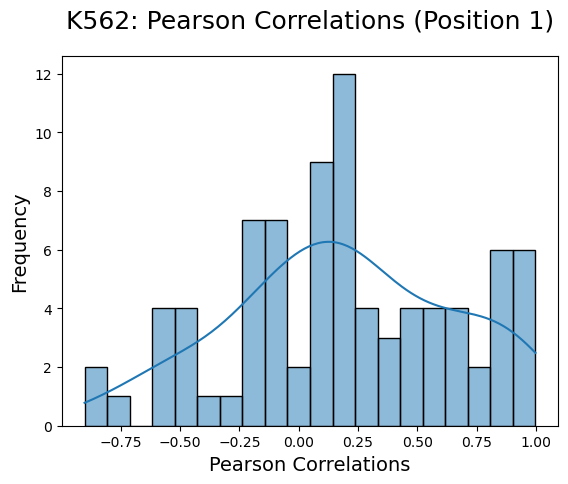

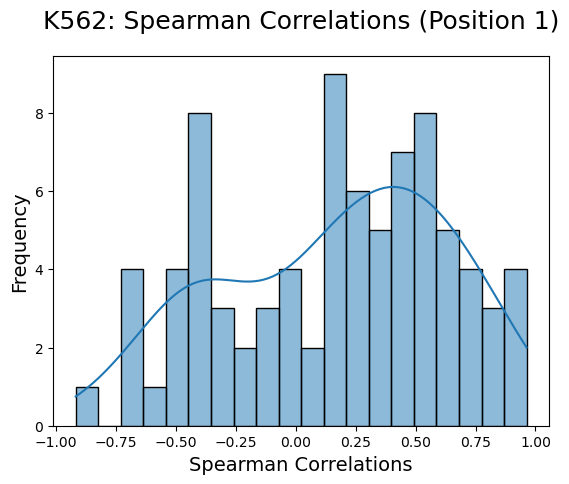

98


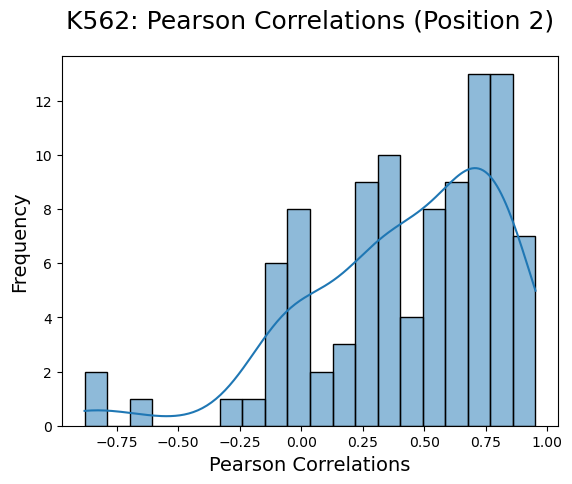

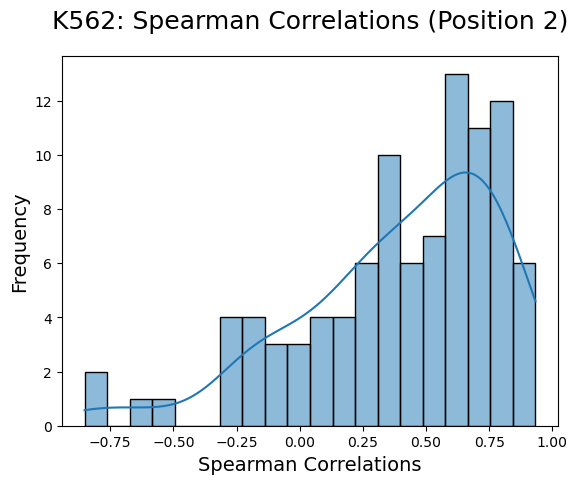

106


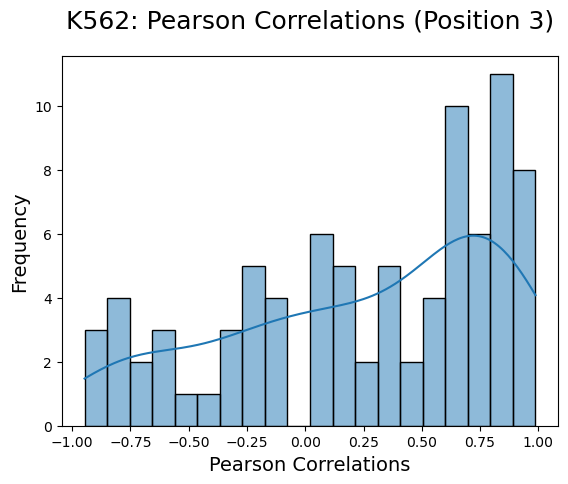

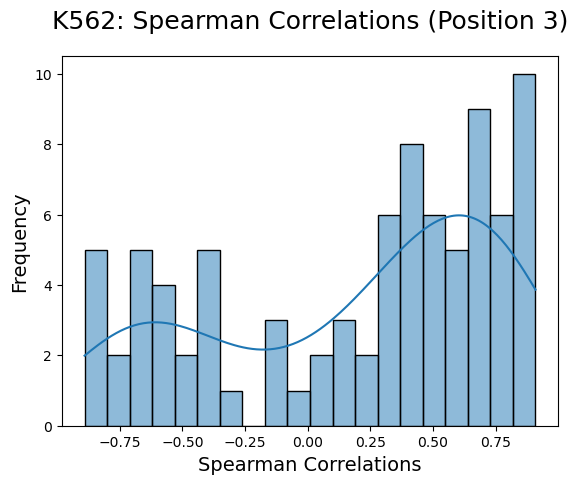

84


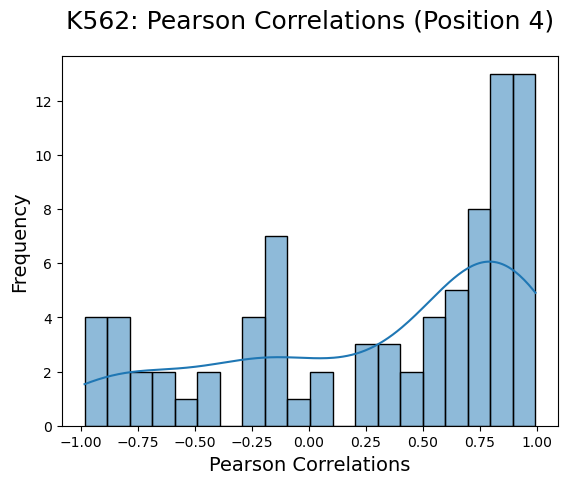

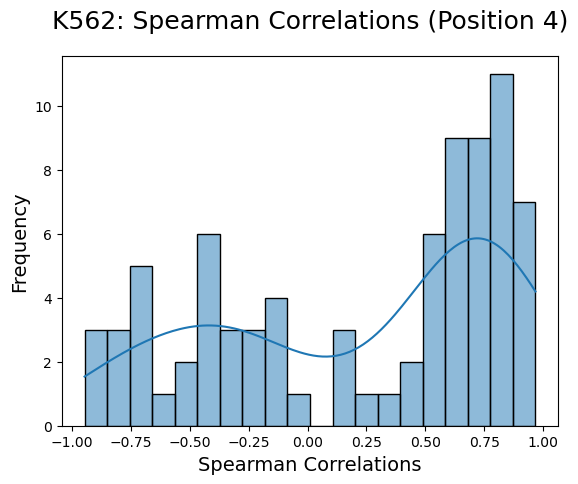

99


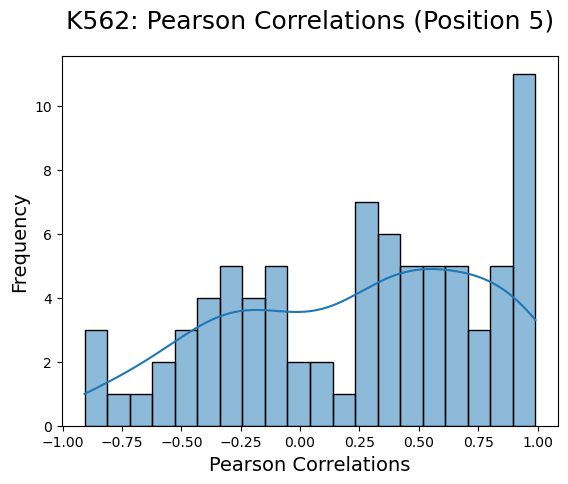

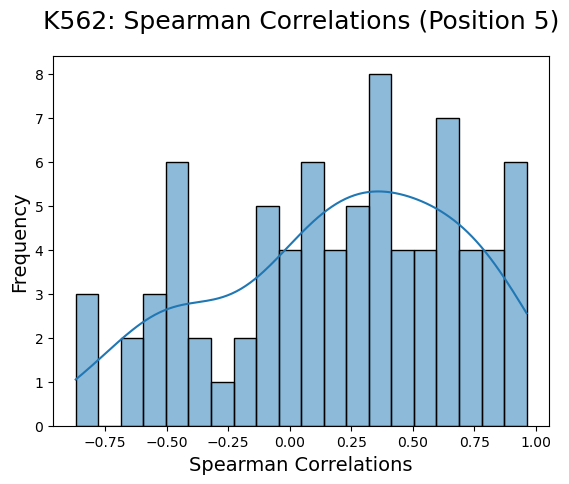

69


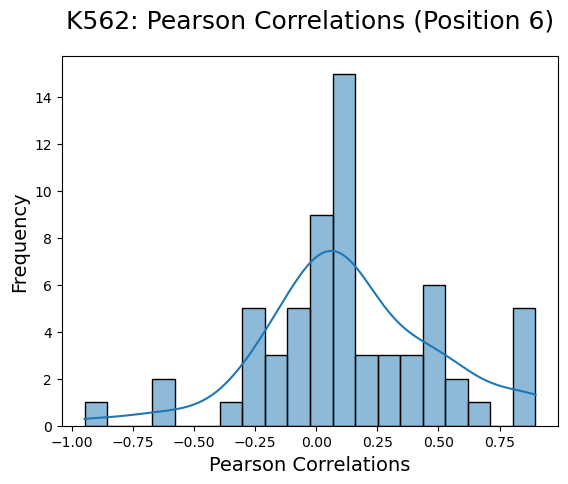

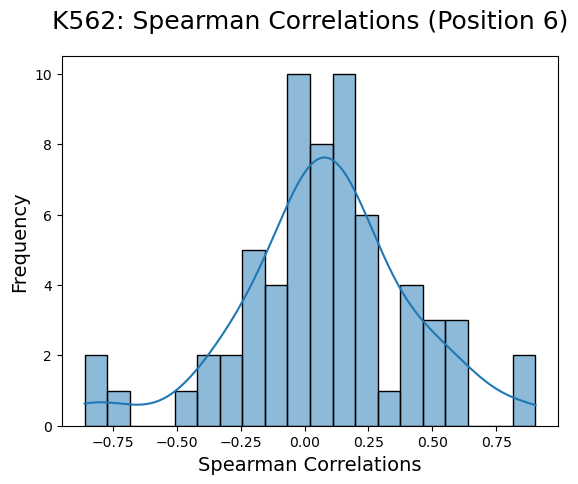

In [7]:
# K562 Distribution of Pearson and Spearman correlations per position

positions = [1, 2, 3, 4, 5, 6]

for pos in positions:
    subset = k562_final[(k562_final["Position"] == pos) & (k562_final["n"] > 30)]
    print(len(subset))
    
    sns.histplot(subset["Pearson_Corr"], kde = True, bins = 20)
    plt.title(f"K562: Pearson Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()
    
    sns.histplot(subset["Spearman_Corr"], kde = True, bins = 20)
    plt.title(f"K562: Spearman Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()
    


547


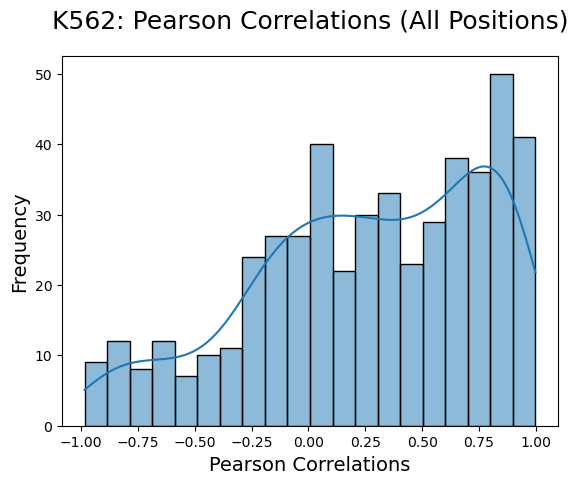

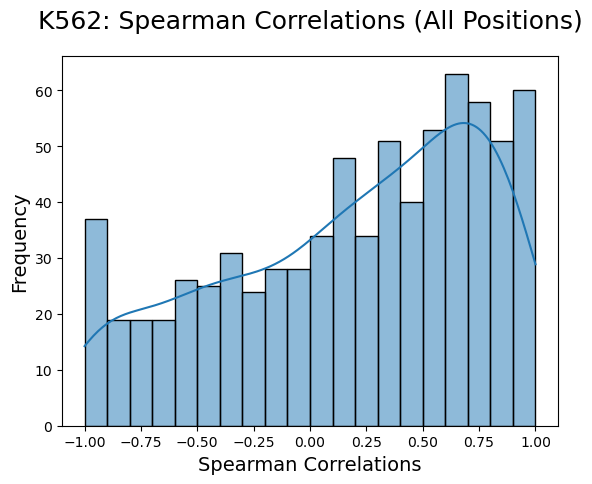

In [8]:
# All positons

subset = k562_final[(k562_final["n"] > 30)]
print(len(subset))

sns.histplot(data = subset, x = "Pearson_Corr", kde = True, bins = 20)
plt.title(f"K562: Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Pearson Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

sns.histplot(data = k562_final, x = "Spearman_Corr", kde = True, bins = 20)
plt.title(f"K562: Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Spearman Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

In [9]:
# Heatmap of PPI pairs and their shap correlations

hepg2_final = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/hepg2_ubp_ppi_shap_correlations.csv')

hepg2_final

,Protein1,Protein2,Position,Pearson_Corr,Pearson_P,Spearman_Corr,Spearman_P,n
0,BCLAF1,BUD13,1,0.438592,6.702090e-41,0.409862,1.901565e-35,842
1,BCLAF1,BUD13,2,0.124273,7.527943e-04,0.430100,2.566042e-34,732
2,BCLAF1,BUD13,3,0.676172,1.839934e-105,0.623414,2.639803e-85,781
3,BCLAF1,BUD13,4,0.554661,6.575447e-53,0.470445,1.473471e-36,640
4,BCLAF1,BUD13,5,0.728274,1.721532e-177,0.683981,1.830973e-148,1070
...,...,...,...,...,...,...,...,...
576,PPIG,U2AF2,2,0.400747,2.896871e-12,0.491024,1.854931e-18,281
577,PPIG,U2AF2,3,0.255542,2.680787e-16,0.583494,7.727651e-92,995
578,PPIG,U2AF2,4,-0.480594,7.977626e-14,-0.504178,2.907445e-15,215
579,PPIG,U2AF2,5,0.187859,3.078872e-14,0.170834,5.354611e-12,1608


In [ ]:
# Pearson Plot

# Get the unique positions
positions = hepg2_final["Position"].unique()

# Loop through each position
for pos in positions:
    subset = hepg2_final[(hepg2_final["Position"] == pos) & (hepg2_final["n"] > 30)]

    # Pivot to heatmap format
    heatmap_data = subset.pivot(
        index="Protein1",
        columns="Protein2",
        values="Pearson_Corr"
    )


    # Make figure scale with matrix size
    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, len(heatmap_data.index) * 0.4))

    ax = sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        cbar_kws={"label": "Pearson Correlation"},
        linewidths=0.5,
        linecolor="lightgray",
        square=False,
        mask=heatmap_data.isna()  # keep NaN cells white
    )

    # Get colorbar and format its label/ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)          # tick labels
    cbar.ax.set_ylabel("Pearson Correaltion", fontsize=18, labelpad=20)  # label

    # Axis labels with font size and labelpad
    plt.xlabel("Protein 2", fontsize=18, labelpad=20)
    plt.ylabel("Protein 1", fontsize=18, labelpad=20)

    # Tick labels
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(rotation=0, fontsize=15)

    # Title
    plt.title(f"HepG2: PPI Pair " + r"$\phi_{i,j}$" + f" Pearson Correlation (Position {pos})", fontsize=20, pad=20)

    plt.tight_layout()
    plt.show()


In [ ]:
# Spearman Plot

# Get the unique positions
positions = hepg2_final["Position"].unique()

# Loop through each position
for pos in positions:
    subset = hepg2_final[(hepg2_final["Position"] == pos) & (hepg2_final["n"] > 30)]

    # Pivot to heatmap format
    heatmap_data = subset.pivot(
        index="Protein1",
        columns="Protein2",
        values="Spearman_Corr"
    )


    # Make figure scale with matrix size
    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, len(heatmap_data.index) * 0.4))

    ax = sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        cbar_kws={"label": "Spearman Correlation"},
        linewidths=0.5,
        linecolor="lightgray",
        square=False,
        mask=heatmap_data.isna()  # keep NaN cells white
    )

    # Get colorbar and format its label/ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)          # tick labels
    cbar.ax.set_ylabel("Spearman Correaltion", fontsize=18, labelpad=20)  # label

    # Axis labels with font size and labelpad
    plt.xlabel("Protein 2", fontsize=18, labelpad=20)
    plt.ylabel("Protein 1", fontsize=18, labelpad=20)

    # Tick labels
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(rotation=0, fontsize=15)

    # Title
    plt.title(f"HepG2: PPI Pair " + r"$\phi_{i,j}$" + f" Spearman Correlation (Position {pos})", fontsize=20, pad=20)

    plt.tight_layout()
    plt.show()

60


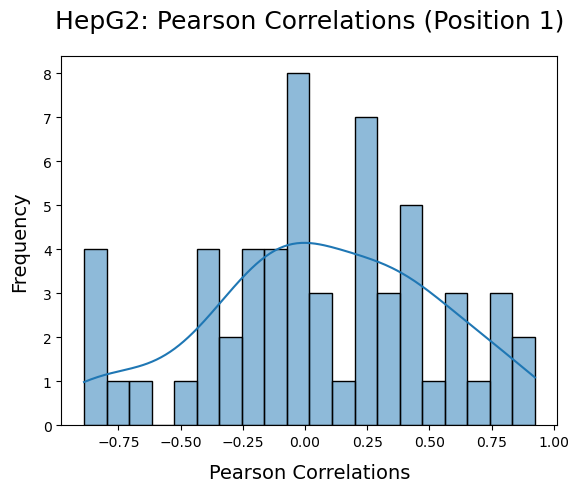

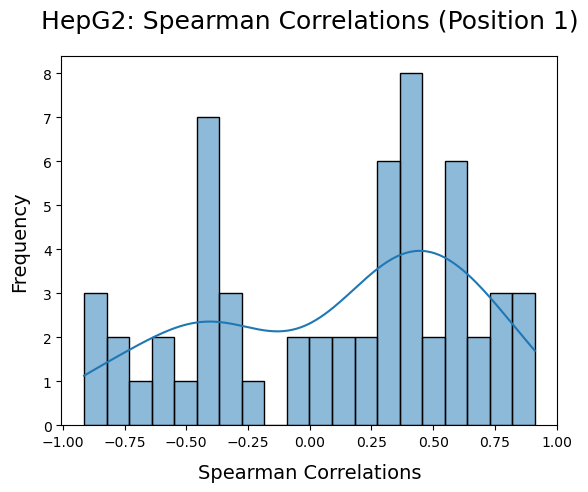

61


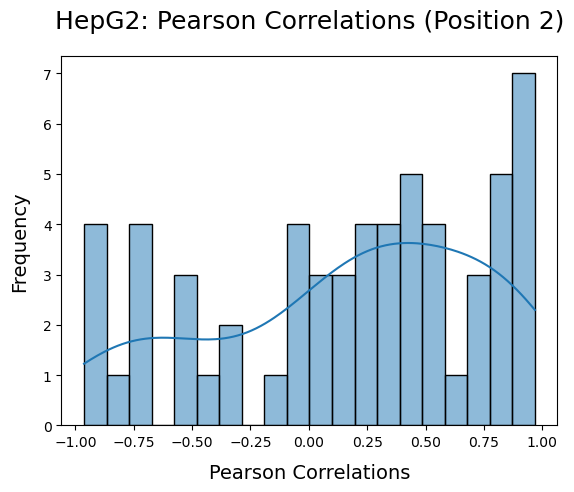

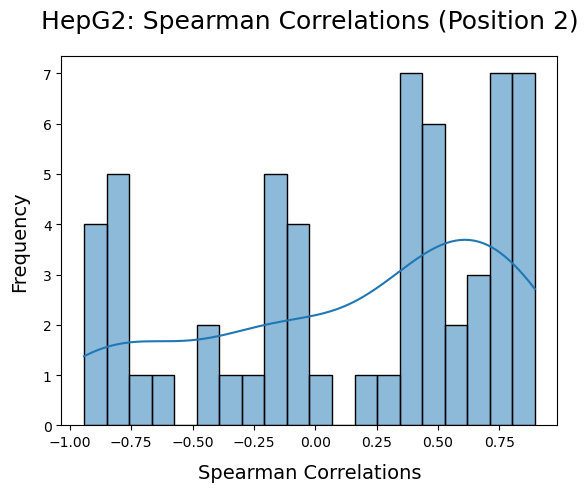

52


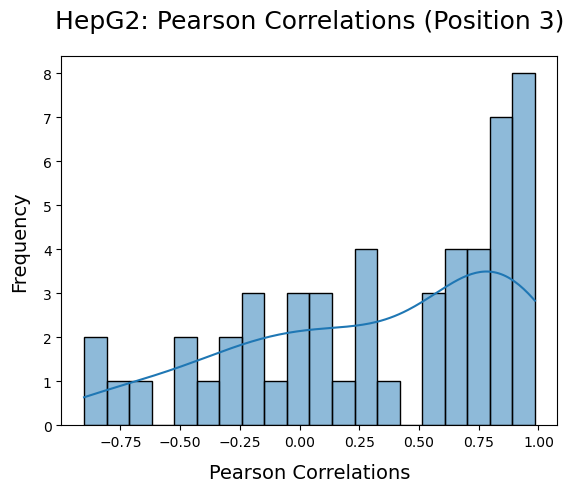

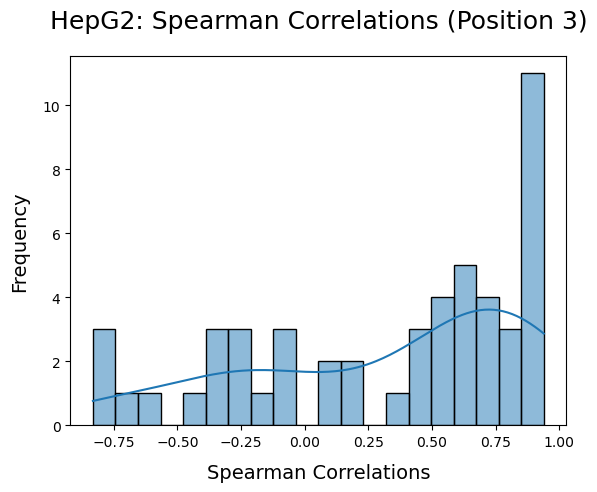

52


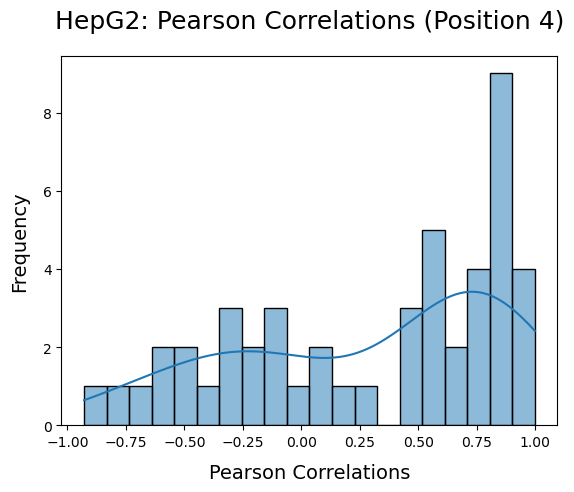

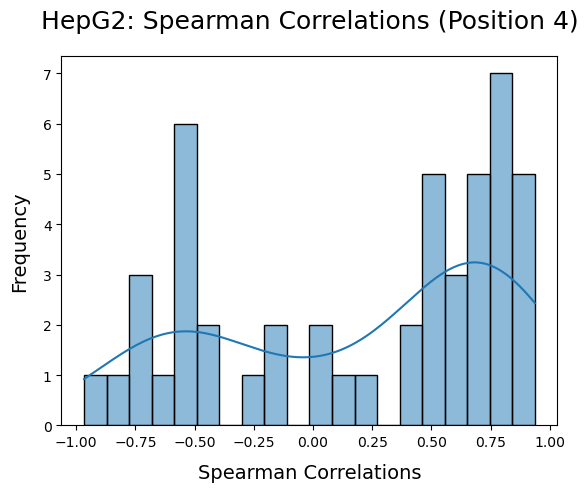

52


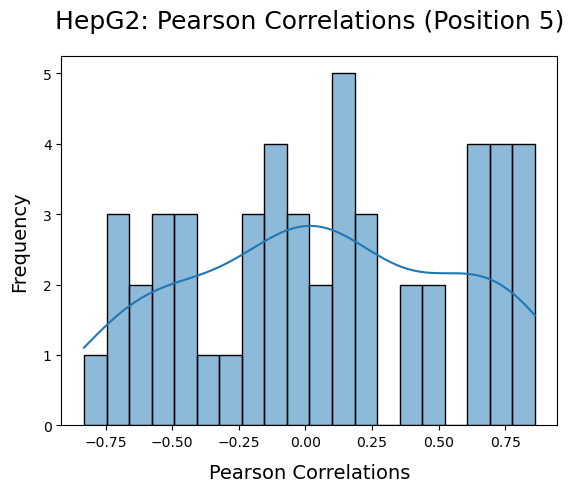

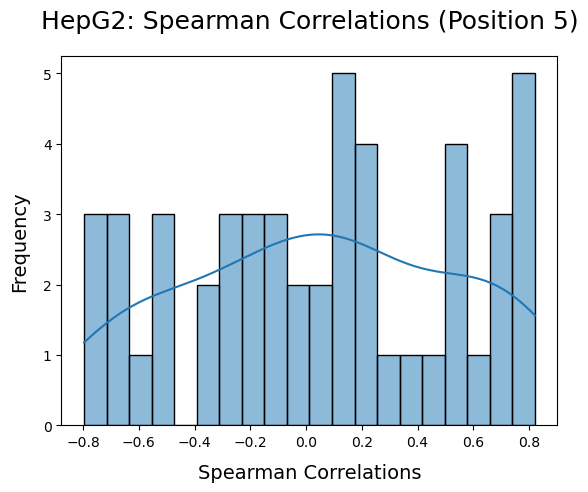

56


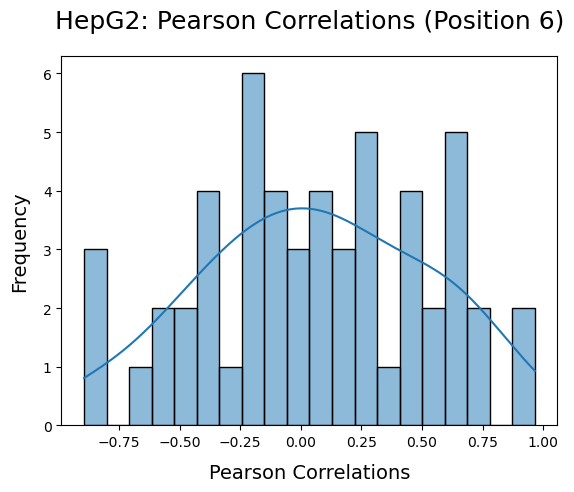

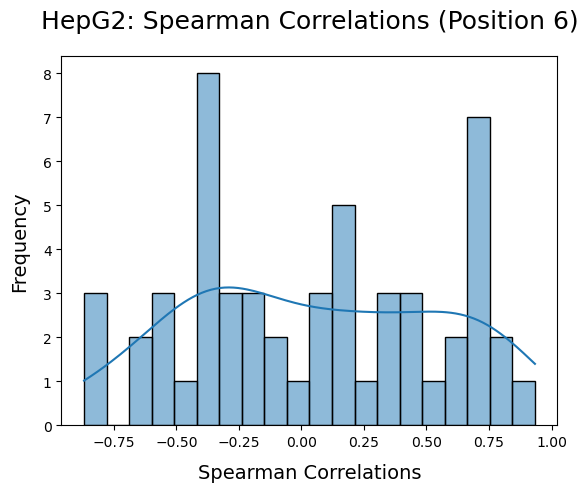

In [10]:
# HepG2 Distribution of Pearson and Spearman correlations per position

positions = {1, 2, 3, 4, 5, 6}

for pos in positions:
    subset = hepg2_final[(hepg2_final["Position"] == pos) & (hepg2_final["n"] > 30)]
    print(len(subset))
    
    sns.histplot(subset["Pearson_Corr"], kde = True, bins = 20)
    plt.title(f"HepG2: Pearson Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14, labelpad = 10)
    plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
    plt.show()
    
    sns.histplot(subset["Spearman_Corr"], kde = True, bins = 20)
    plt.title(f"HepG2: Spearman Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14, labelpad = 10)
    plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
    plt.show()

333


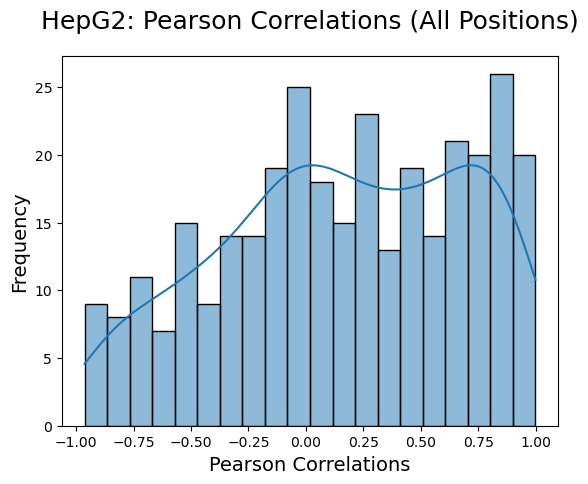

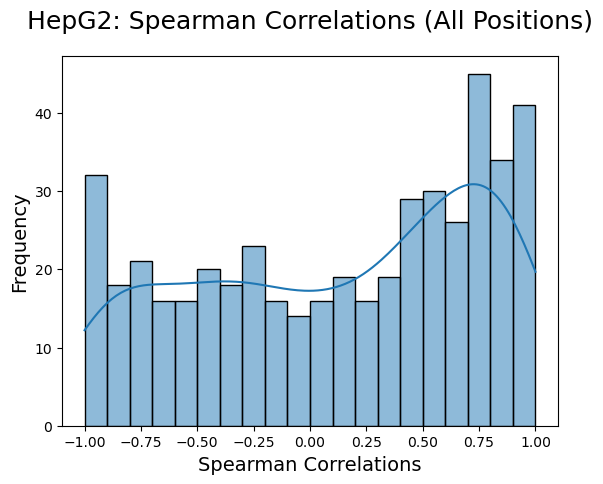

In [11]:
# All positons

subset = hepg2_final[(hepg2_final["n"] > 30)]
print(len(subset))

sns.histplot(data = subset, x = "Pearson_Corr", kde = True, bins = 20)
plt.title(f"HepG2: Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Pearson Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

sns.histplot(data = hepg2_final, x = "Spearman_Corr", kde = True, bins = 20)
plt.title(f"HepG2: Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Spearman Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()